In [1]:
from utils.data_loader import load_breast_cancer_data, load_folktables_income_data, load_loan_prediction, \
    load_gbs_gesis, load_gbs_allensbach, load_folktables_employment_data
import seaborn as sns
import numpy as np
seed = 5
np.random.seed(seed)
random_generator = np.random.RandomState(seed)
from utils.sampling import  sample_with_test_set
from sklearn.preprocessing import StandardScaler
from weighting_methods.feature_weighted_maximum_representative_subsampling import  mrs_step

2024-11-14 14:40:09.638532: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-14 14:40:10.630384: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def compute_undersampled_feature_weights_with_temperature(temperature, feature_importance):
    """_summary_

    :param temperature: _description_
    :param feature_importance: _description_
    :return: _description_
    """
    if temperature is None or temperature == 0.0:
        return np.ones(len(feature_importance)) / len(feature_importance)
    feature_weights = np.exp(-np.array(feature_importance) / temperature)
    return feature_weights / np.sum(feature_weights)

In [34]:
df, columns, target = load_folktables_income_data()
df[columns] = StandardScaler().fit_transform(df[columns])
# N = df[df["label"] == 1]
# R = df[df["label"] == 0]
N, R, T = sample_with_test_set(
           "less_positive_class",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.1,
           test_fraction=0.1,
           columns=columns,
           random_generator=None,
       )
dropped_N = N.copy().reset_index(drop=True)
feature_weights = np.ones(len(columns)) / len(columns)

In [35]:
# _, feature_importance = mrs_without_cv(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20, feature_weights=feature_weights)
drop_ids, feature_importance, _ = mrs_step(dropped_N, R, columns, target, random_state=seed, drop=20, feature_weight=feature_weights, \
                                         sample_weights=np.ones(len(dropped_N)), compute_feature_importance=True)

 99%|===================| 646/650 [01:16<00:00]        

<Axes: >

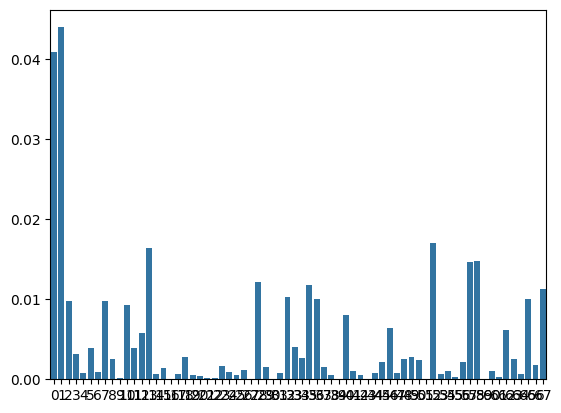

In [36]:
sns.barplot(feature_importance)

<Axes: >

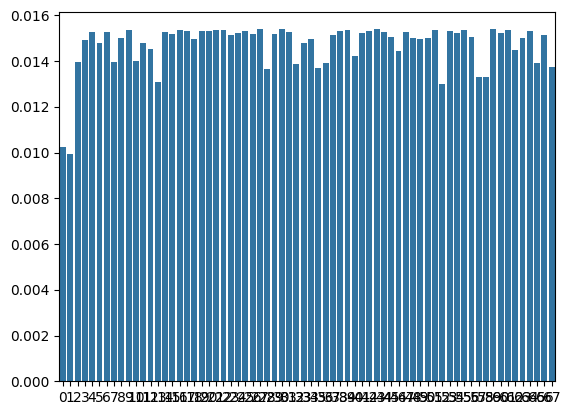

In [37]:
feature_weights = compute_undersampled_feature_weights_with_temperature(0.1, feature_importance)
sns.barplot(feature_weights)

In [38]:
seed = 5
max_features = "sqrt"
sample_weights = np.ones(len(N)) / len(N)
n_estimators=200

feature_weights_list = []
# budgets = [None, 0.1, 0.01, 0.005, 0.001]
# budgets = [None, 0.1, 0.05, 0.01, 0.005]
budgets = [0.0, 0.1, 0.05, 0.01, 0.005, 0.001]
for budget in budgets:
    feature_weights = compute_undersampled_feature_weights_with_temperature(budget, feature_importance)
    feature_weights_list.append(feature_weights)

In [39]:
from utils.metrics import train_random_forest_classifier

clf, score = train_random_forest_classifier(
                    N[columns].values,
                    N[target].values,
                    sample_weights,
                    np.array(feature_weights_list[0]),
                    random_state=None,
                    n_splits=5,
                    draw_with_feature_weights=False,
                    n_estimators=n_estimators,
                    max_features=max_features,
                )
print(score)

0.8374350052564971


None: 0.736641852770885\
0.1: 0.7363564929693963\
0.05: 0.7360835401157982\
0.01: 0.7117038875103391\
0.005: 0.7074276261373036